In [10]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [12]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [13]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
block_size = 3

def build_dataset(words):
    block_size = 3 # context length
    X, Y = [], []
    for w in words:

        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [14]:
# MLP revisited
n_embd = 10 # dimensionality of the character embedding vectors
n_hidden = 200 # the nr. of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size)**0.5)  #* 0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # the nr. of params in total
for p in parameters:
    p.requires_grad = True

11897


In [52]:
(torch.randn(10000) * 0.2).std()

tensor(0.1986)

In [53]:
(5/3) / (30**0.5)

0.3042903097250923

tensor(0.0155) tensor(0.9963)
tensor(-0.0013) tensor(1.0068)


(array([6.66987680e-05, 4.44658453e-05, 6.66987680e-05, 1.11164613e-04,
        3.11260917e-04, 2.44562149e-04, 5.33590144e-04, 1.02271444e-03,
        1.53407166e-03, 2.49008734e-03, 4.55774914e-03, 6.69210972e-03,
        1.05828712e-02, 1.74528443e-02, 2.70130010e-02, 4.18201275e-02,
        5.90506426e-02, 8.67973300e-02, 1.24882327e-01, 1.70993408e-01,
        2.28287650e-01, 2.87827417e-01, 3.53214442e-01, 3.98725235e-01,
        4.26894348e-01, 4.27805898e-01, 3.91855262e-01, 3.41297596e-01,
        2.82291419e-01, 2.19550111e-01, 1.64367997e-01, 1.20880400e-01,
        8.42850098e-02, 5.50709494e-02, 3.80627636e-02, 2.51009697e-02,
        1.71860492e-02, 1.08941321e-02, 6.55871218e-03, 4.26872115e-03,
        2.37892272e-03, 1.60077043e-03, 8.44851061e-04, 5.33590144e-04,
        2.44562149e-04, 6.66987680e-05, 4.44658453e-05, 1.11164613e-04,
        2.22329227e-05, 4.44658453e-05]),
 array([-5.60899925, -5.38410754, -5.15921583, -4.93432412, -4.70943241,
        -4.4845407 , 

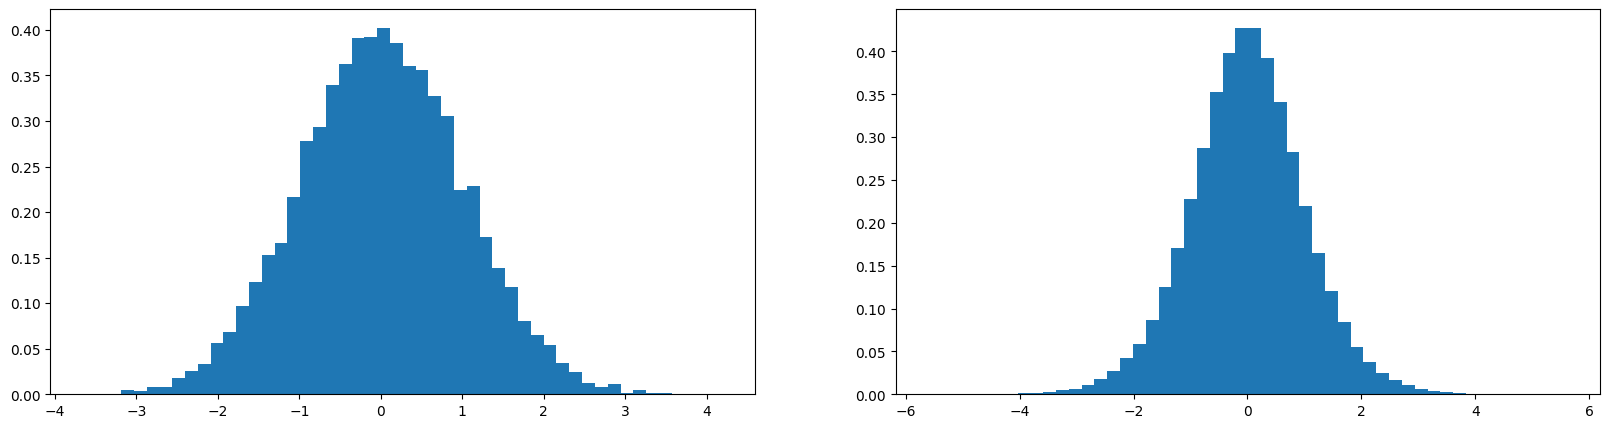

In [6]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)
# We want y to follow a Standard/Gaussian distribution so we divide the w by the square root of the nr of x's columns

In [55]:
hpreact.shape

torch.Size([32, 200])

In [57]:
hpreact.mean(0, keepdim=True).shape

torch.Size([1, 200])

In [58]:
hpreact.std(0, keepdim=True).shape

torch.Size([1, 200])

In [72]:
batch_size = 32
lossi = []

for i in range(30000):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # Batch X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # cat the vectors
    # Linear layer
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # from the Normalization via Mini-Batch Statistics paper --> Basically forces to follow Gaussian distribution

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    # -------------------------------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 10000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{20000}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/20000: 3.3100
  10000/20000: 2.3139
  20000/20000: 2.0198


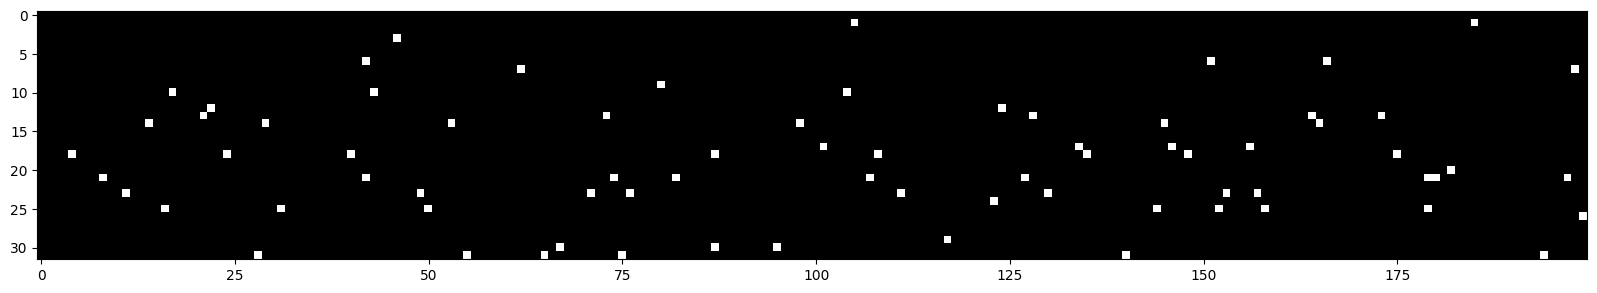

In [64]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')
# If all examples lead in the tail, the neuron doesnt learn, it is dead: a row is a neuron in the plot (0-white; 1-black)

In [23]:
h, h.shape

(tensor([[ 0.9997, -0.9997, -1.0000,  ...,  0.9998, -0.9998, -1.0000],
         [-0.9999, -1.0000, -1.0000,  ..., -0.9916, -1.0000, -0.9936],
         [-0.9957,  0.8787, -1.0000,  ...,  1.0000, -1.0000, -1.0000],
         ...,
         [-0.9896, -0.9997, -0.9642,  ...,  0.9004, -1.0000, -0.9994],
         [ 0.7532, -0.9938,  0.9996,  ..., -0.9995,  0.9998,  1.0000],
         [ 0.9941, -1.0000, -1.0000,  ..., -1.0000, -0.9983, -0.8492]],
        grad_fn=<TanhBackward0>),
 torch.Size([32, 200]))

(array([2226.,  144.,   95.,   63.,   54.,   49.,   40.,   38.,   26.,
          30.,   29.,   27.,   21.,   21.,   20.,   22.,   29.,   26.,
          24.,   15.,   26.,   29.,   15.,   24.,   17.,   25.,   14.,
          15.,   25.,   24.,   19.,   26.,   26.,   25.,   17.,   26.,
          27.,   24.,   29.,   29.,   29.,   20.,   46.,   34.,   43.,
          67.,   63.,   90.,  152., 2395.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

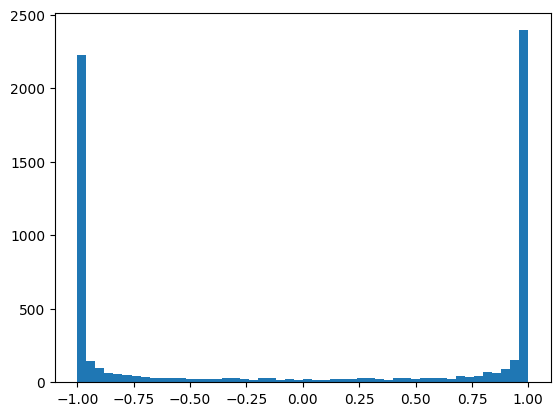

In [26]:
plt.hist(h.view(-1).tolist(), 50)

(array([  1.,   0.,   3.,   4.,   6.,  12.,  12.,  20.,  15.,  28.,  40.,
         51.,  79., 100., 105., 147., 167., 221., 253., 272., 288., 333.,
        341., 357., 421., 373., 356., 351., 307., 294., 261., 238., 180.,
        167., 138., 111.,  95.,  55.,  57.,  38.,  25.,  26.,  15.,  10.,
          9.,   7.,   5.,   4.,   0.,   2.]),
 array([-19.89120674, -19.08281242, -18.27441811, -17.46602379,
        -16.65762947, -15.84923515, -15.04084084, -14.23244652,
        -13.4240522 , -12.61565788, -11.80726357, -10.99886925,
        -10.19047493,  -9.38208061,  -8.57368629,  -7.76529198,
         -6.95689766,  -6.14850334,  -5.34010902,  -4.53171471,
         -3.72332039,  -2.91492607,  -2.10653175,  -1.29813744,
         -0.48974312,   0.3186512 ,   1.12704552,   1.93543983,
          2.74383415,   3.55222847,   4.36062279,   5.16901711,
          5.97741142,   6.78580574,   7.59420006,   8.40259438,
          9.21098869,  10.01938301,  10.82777733,  11.63617165,
         12.444565

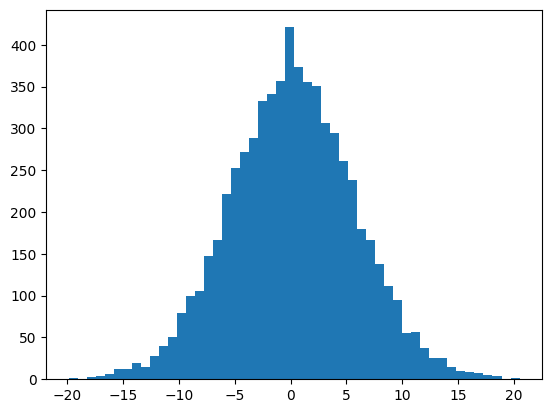

In [28]:
plt.hist(hpreact.view(-1).tolist(), 50)

In [14]:
logits[0]

tensor([ 5.0532,  3.4514,  2.3695,  2.3655,  7.0964,  3.4569,  1.3185,  1.4603,
         2.5766,  2.7291, -2.3692,  5.0419,  8.9863,  2.4271,  6.4090, -0.1564,
        -1.3259, -1.8109,  6.1262,  5.5844,  4.7642,  3.0173,  4.0243,  1.2474,
         3.9402,  4.0756, -0.0498], grad_fn=<SelectBackward0>)

In [12]:
-torch.tensor(1/27.0).log()

tensor(3.2958)

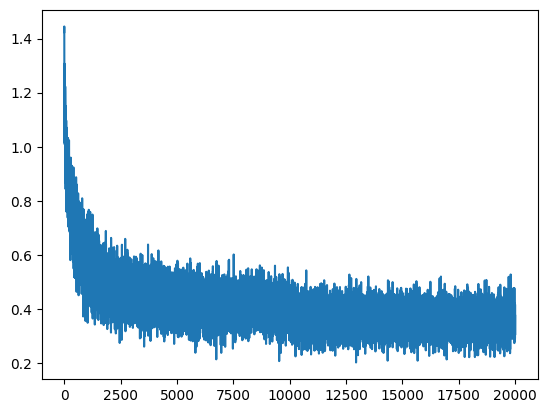

In [8]:
plt.plot(lossi)

In [73]:
# calibrate the batch norm at the end of training

with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std dev over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [74]:
bnmean

tensor([[-1.1471e+00,  4.2468e-03, -9.0079e-01,  8.7861e-01,  8.7325e-01,
          4.9418e-01,  1.3372e+00, -5.0562e-01,  1.7461e-01,  7.1625e-01,
         -1.2186e+00, -1.4766e+00, -1.9942e-01, -3.6282e-01, -2.1410e-01,
          4.9269e-01,  5.7388e-01, -1.4430e+00, -2.7791e-01,  6.4663e-01,
          3.7045e-01, -3.7097e-01, -1.1266e-01,  5.5810e-01,  5.0413e-01,
          7.5269e-01,  7.0154e-01, -1.5369e-01,  8.9086e-02,  8.8576e-01,
         -4.8489e-01, -8.4658e-01,  2.8771e-01,  4.0156e-01, -2.6681e-01,
         -7.0163e-01, -6.2514e-01, -3.2138e-01, -5.2677e-02,  4.3973e-01,
         -1.2077e-01, -9.2679e-01, -6.0248e-01,  1.1586e-01,  5.8474e-01,
          1.0321e-01,  4.4755e-01, -4.4220e-01,  8.0472e-01,  1.2126e+00,
          5.2793e-01,  1.1587e-01,  1.2492e+00,  1.1159e+00,  8.3049e-01,
         -1.1274e+00, -1.5644e-01,  5.3971e-01,  1.4553e+00, -7.3441e-01,
         -5.1763e-01,  3.5005e-01,  3.1157e-01,  3.0605e-02,  1.2513e+00,
          6.2483e-01,  1.6970e-01,  7.

In [75]:
bnmean_running

tensor([[-1.1539e+00, -6.6362e-04, -8.8675e-01,  8.7461e-01,  8.6244e-01,
          5.1182e-01,  1.3389e+00, -5.0622e-01,  1.6836e-01,  7.1838e-01,
         -1.2184e+00, -1.4754e+00, -1.8818e-01, -3.6996e-01, -2.0428e-01,
          4.9492e-01,  5.7354e-01, -1.4362e+00, -2.6248e-01,  6.5013e-01,
          3.8560e-01, -3.7983e-01, -1.1247e-01,  5.5504e-01,  4.9415e-01,
          7.5911e-01,  7.1456e-01, -1.4375e-01,  1.0002e-01,  9.0439e-01,
         -4.7569e-01, -8.4835e-01,  3.0139e-01,  4.0762e-01, -2.7730e-01,
         -7.0531e-01, -6.2608e-01, -3.3946e-01, -4.0629e-02,  4.5343e-01,
         -1.1275e-01, -9.3676e-01, -5.9515e-01,  1.2199e-01,  5.7409e-01,
          9.6509e-02,  4.4607e-01, -4.4831e-01,  8.0381e-01,  1.2239e+00,
          5.1887e-01,  1.1160e-01,  1.2522e+00,  1.1301e+00,  8.3694e-01,
         -1.1390e+00, -1.5074e-01,  5.2814e-01,  1.4644e+00, -7.2709e-01,
         -5.0323e-01,  3.4034e-01,  3.1432e-01,  2.7662e-02,  1.2514e+00,
          6.3292e-01,  1.8255e-01,  6.

In [87]:
@torch.no_grad() # This disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias # from the Normalization via Mini-Batch Statistics paper --> Basically forces to follow Gaussian distribution
    h = torch.tanh(hpreact) # hidden layer
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
# split_loss('test')

train 2.4341955184936523
val 2.438976287841797


In [86]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 8)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print the generated word

prevn.
zory.
pers.
raiduyah.
kulbrak.
glidah.
zavie.
bdo.
taravjiebrrenoradann.
suth.
malyck.
rannz.
makkimstleyza.
kulmeblan.
brraulilangrysh.
malismaroy.
zen.
krandrug.
bries.
anybn.


In [ ]:
# SUMMARY ------------------

In [7]:
# Lets train a deeper network

class Linear:
    def __init__(self, fan_in, fan_out, bias=True, device=None):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in **0.5
        self.bias = torch.zeros(fan_out) if bias else None
        #self.device = torch.device('gpu' if  torch.cuda.is_available else 'cpu')

    def __call__(self, X):
        self.out = X @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # params (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, X):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []
    
n_embd = 10 # dimensionality of the character embedding vectors
n_hidden = 10 # nr of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear((n_embd * block_size), n_hidden, BatchNorm1d(n_hidden), Tanh()),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # nr of params in total
for p in parameters:
    p.requires_grad = True

1451


In [9]:
max_steps = 100000
batch_size = 32
lossi = []
ud = []
for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.5 #0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log().item() for p in parameters])
    
    #break
ud
# ud stands for update-to-data ratio

      0/ 100000: 2.1716
  10000/ 100000: 2.1110
  20000/ 100000: 2.4188
  30000/ 100000: 2.0537
  40000/ 100000: 2.2759
  50000/ 100000: 2.2348
  60000/ 100000: 2.4260
  70000/ 100000: 2.3769
  80000/ 100000: 2.4098
  90000/ 100000: 2.5168


[[-6.22910213470459,
  -6.0058274269104,
  -6.278902530670166,
  -6.014767646789551,
  -6.630010604858398,
  -3.444491147994995,
  -4.419473648071289,
  -5.967625141143799,
  -6.2214460372924805,
  -3.232207775115967,
  -3.3945610523223877,
  -5.9699273109436035,
  -6.196983337402344,
  -3.8120570182800293,
  -3.9016165733337402,
  -5.9164347648620605,
  -6.09552001953125,
  -2.658440113067627,
  -3.8405144214630127,
  -5.942936897277832,
  -5.624403953552246,
  -4.487558841705322,
  -4.1363372802734375],
 [-6.433350086212158,
  -6.372156143188477,
  -6.434078216552734,
  -6.173214912414551,
  -7.236387729644775,
  -3.4202804565429688,
  -3.7797563076019287,
  -6.104363918304443,
  -6.267667293548584,
  -3.270923614501953,
  -3.6245856285095215,
  -6.1010026931762695,
  -6.257091999053955,
  -4.400222301483154,
  -3.996506452560425,
  -6.28346586227417,
  -5.920083522796631,
  -3.294898509979248,
  -3.831071615219116,
  -6.065250873565674,
  -5.998703479766846,
  -4.113789081573486,
  

In [118]:
torch.tensor(ud).shape

torch.Size([1000, 23])

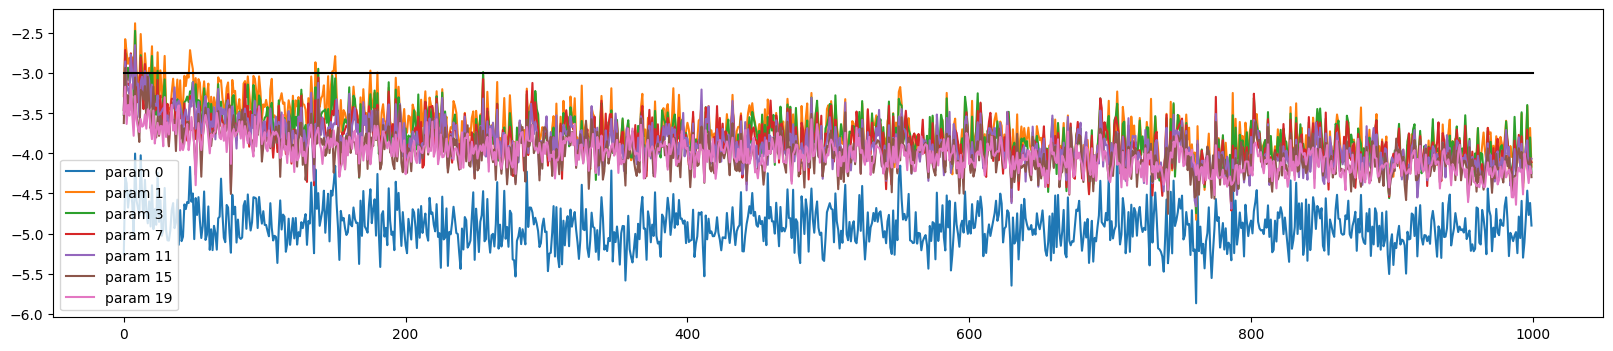

In [119]:
plt.figure(figsize=(20,4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these rations should be ~1e-3, indicate on plot
plt.legend(legends);